# Query and plot submitted GlaMBIE-2 data

Demo on how to use the glambie code to query and show data from the submission system for GlaMBIE-2 as well as compare to GlaMBIE-1


In [ ]:
import matplotlib.pyplot as plt
import urllib.request as url
import pandas as pd
import numpy as np
import os
from glambie.data.timeseries import Timeseries, TimeseriesData
from glambie.data.data_catalogue import DataCatalogue
from glambie.const.regions import REGIONS
from glambie.plot.plot_helpers import get_colours, add_labels_axlines_and_title, plot_non_cumulative_timeseries_on_axis, plot_cumulative_timeseries_on_axis
from glambie.data import submission_system_interface

#### Query and filter data

In [ ]:
# read catalogue - this might take a while to download data from the submission system
glambie_bucket_name = "glambie2-submissions"
catalogue_original = DataCatalogue.from_glambie_submission_system(glambie_bucket_name=glambie_bucket_name)

In [ ]:
# filter catalogue by region:
region = "iceland"
catalogue_filtered = catalogue_original.get_filtered_catalogue(region_name=region)

In [ ]:
# Let's print all datasets in the filtered catalogue
for d in catalogue_filtered.datasets:
    print(f"{d.region.name} \t RGI:{d.rgi_version:15.15} \t {d.data_group.name} \t {d.user_group}")

### Plot all datasets from one group 

Now we will filter by region (as defined above) and data group (DEM Differencing) and plot all the datasets in one plot

In [ ]:
# filter catalogue by region and datagroup
catalogue_filtered_group = catalogue_original.get_filtered_catalogue(
    region_name=region, data_group="demdiff"
)
plot_errors = True  # set to True if you want to plot error bars

_, axes = plt.subplots(2, 1, figsize=(11, 6))
colours = get_colours(len(catalogue_filtered_group.datasets) + 1)
# plot non-cumulative timeseries
for count, ds in enumerate(catalogue_filtered_group.datasets):
    plot_non_cumulative_timeseries_on_axis(
        result_dataframe=ds.data.as_dataframe(),
        ax=axes[0],
        colour=colours[count],
        plot_errors=plot_errors,
    )

# plot cumulative timeseries
for count, ds in enumerate(catalogue_filtered_group.datasets):
    plot_cumulative_timeseries_on_axis(
        timeseries=ds,
        ax=axes[1],
        colour=colours[count],
        plot_errors=plot_errors,
        linestyle="-",
        timeseries_for_vertical_adjustment=None,  # you can set this to a particular reference timeseries if you don't want the cumulative timeseries starting at 0 for each dataset
        label="Dataset: " + ds.user_group,
    )

add_labels_axlines_and_title(
    axes=axes,
    unit=catalogue_filtered_group.datasets[0].unit,
    legend_fontsize=9,
    title=REGIONS[region].name,
)

### Pick one dataset and look at it

We'll now pick out one dataset and look at its data and metadata and perform some simple operations

In [ ]:
# pick a dataset to look at
dataset = catalogue_filtered.datasets[2]
# print some metadata
print(
    f"region = {dataset.region.name} \t data_group/source = {dataset.data_group.name} \t author group = {dataset.user_group}  \t unit = {dataset.unit}  \t RGI version = {dataset.rgi_version}"
)

In [ ]:
# show first few rows of data of that dataset
dataset.data.as_dataframe()

In [ ]:
# Show some more metadata...
# The metadata comes as a dictionary, here are the keys:
print(dataset.additional_metadata.keys())
# for example let's pick one key show co-authors
print("Co-Authors: ", dataset.additional_metadata["co_author_names"])

In [ ]:
# Example how to convert to a different unit (in this case we convert from meter water equivalent to Gigatonnes)
dataset_in_mwe = dataset.convert_timeseries_to_unit_mwe(rgi_area_version=6)
dataset_in_mwe.data.as_dataframe().head()

In [ ]:
# now the datasets have different units
dataset.unit, dataset_in_mwe.unit

In [ ]:
# Is area change applied? 
dataset_in_mwe.area_change_applied

In [ ]:
# Let's apply the area change
dataset_with_area_change = dataset_in_mwe.apply_or_remove_area_change(rgi_area_version=6, apply_area_change=True)
print(dataset_with_area_change.area_change_applied)
dataset_with_area_change.data.as_dataframe().head()

#### Download GlaMBIE-1 results for comparison

In [ ]:
# Download data from WGMS and unzip
glambie1_foldername = "GlaMBIE_Data_DOI_10.5904_wgms-glambie-2024-07.zip"
if not os.path.exists(glambie1_foldername):
    url.urlretrieve(f"https://wgms.ch/downloads/{glambie1_foldername}", glambie1_foldername)
    !unzip {glambie1_foldername}

In [ ]:
# Read GlaMBIE-1 Alaska CSV and convert it into TimeseriesData + Timeseries
data_directory = os.path.join('glambie_results_20240716/hydrological_years/')
region_csv_path = os.path.join(data_directory, f"{REGIONS[region].rgi_id}_{region}.csv")
region_df = pd.read_csv(region_csv_path)

# Read into the same format as the other datasets
# For now we are reading the combined dataset, but you can also read the individual datasets (e.g. altimetry-only)
data = TimeseriesData(
    start_dates=np.array(region_df["start_dates"]), end_dates=np.array(region_df["end_dates"]),
    changes=np.array(region_df["combined_mwe"]), errors=np.array(region_df["combined_mwe_errors"])
)
glambie1_timeseries = Timeseries(
    region=REGIONS[region], data=data, user_group="GlaMBIE-1 combined", rgi_version=6, unit="mwe",
)

glambie1_timeseries.data.as_dataframe().head()

#### Plot datasets again with GlaMBIE-1

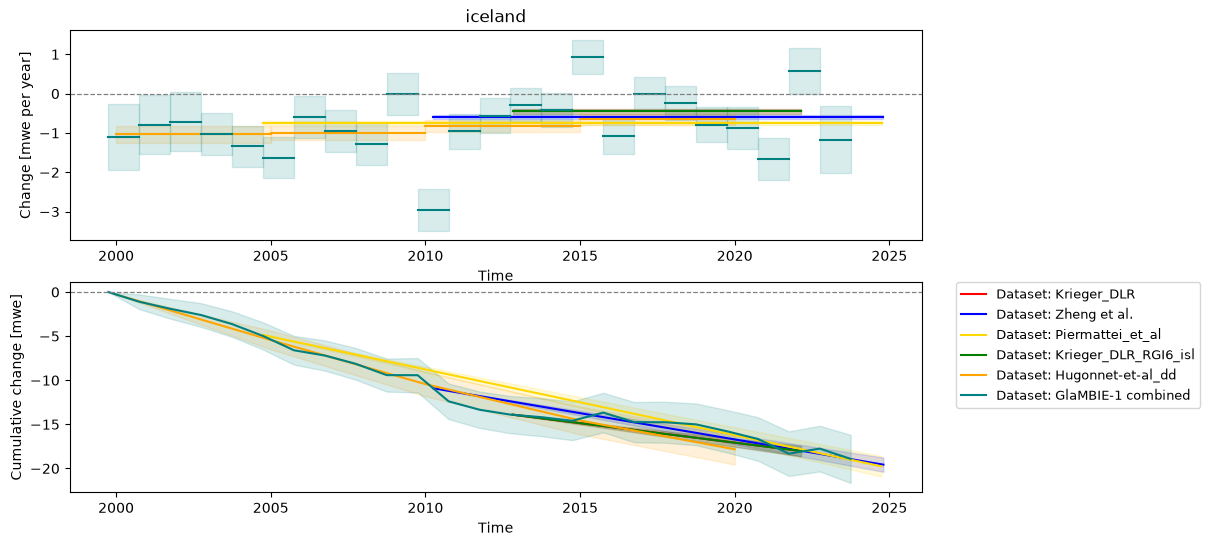

In [ ]:
# filter catalogue by region and datagroup
plot_errors = True  # set to True if you want to plot error bars

catalogue_filtered_group = catalogue_original.get_filtered_catalogue(
    region_name=region, data_group="demdiff"
)
catalogue_filtered_group.datasets.append(glambie1_timeseries)  # add the GlaMBIE-1 timeseries to the catalogue
# convert all datasets to mwe and reload into catalogue. Note that if a dataset is already in mwe it will be left unchanged
catalogue_filtered_group = DataCatalogue.from_list(
    [ds.convert_timeseries_to_unit_mwe(rgi_area_version=6) for ds in catalogue_filtered_group.datasets]
)

_, axes = plt.subplots(2, 1, figsize=(11, 6))
colours = get_colours(len(catalogue_filtered_group.datasets) + 1)
# plot non-cumulative timeseries
for count, ds in enumerate(catalogue_filtered_group.datasets):
    plot_non_cumulative_timeseries_on_axis(
        result_dataframe=ds.data.as_dataframe(),
        ax=axes[0],
        colour=colours[count],
        plot_errors=plot_errors,
    )

# plot cumulative timeseries
for count, ds in enumerate(catalogue_filtered_group.datasets):
    plot_cumulative_timeseries_on_axis(
        timeseries=ds,
        ax=axes[1],
        colour=colours[count],
        plot_errors=plot_errors,
        linestyle="-",
        timeseries_for_vertical_adjustment=catalogue_filtered_group.datasets[-1],  # let's align all datasets to the GlaMBIE-1 timeseries
        label="Dataset: " + ds.user_group,
    )

add_labels_axlines_and_title(
    axes=axes,
    unit=catalogue_filtered_group.datasets[0].unit,
    legend_fontsize=9,
    title=REGIONS[region].name,
)

#### Download dataset information PDF of dataset

Download the PDF submitted by the participants

In [ ]:
# download PDF (by default it will be in the same directory as notebook is run unless target directory is specified)
submission_system_interface.download_dataset_information_file_to_disk(
    user_group=dataset.user_group,
    data_group=dataset.data_group,
    target_directory=".",
    glambie_bucket_name=glambie_bucket_name
)